In [1]:
from typing import List, Optional, Tuple

import hydra
import torch
import pytorch_lightning as pl
from omegaconf import DictConfig
from pytorch_lightning import Callback, LightningDataModule, LightningModule, Trainer
from pytorch_lightning.loggers import LightningLoggerBase
from models.module import PatchClassificationModule
from models.model import construct_PPNet
from models.push import push_prototypes
import json
import random
import netCDF4
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch.nn.functional as F

/home/ines/televit_xai/xai/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
input_vars = [
    'lst_day',
    'ndvi',
    'rel_hum',
    'ssrd',
    'sst',
    't2m_min',
    'tp',
    'vpd']


path = "/data/ines/positive_batches/train/"

#extran mean for normalisation
path_mean = "/data/ines/positive_batches/train/mean_std.json"
with open(path_mean, 'r') as json_file:
    mean_std_dict = json.load(json_file)


batch_files = [filename for filename in os.listdir(path) if filename.startswith('batch')]



In [3]:
# last_checkpoint = os.path.join('/home/ines/televit_xai/results/kld_checkpoint/nopush_best.pth')
# #checkpoint = torch.load('/home/ines/televit_xai/logs/train/runs/2024-11-14_20-06-56/checkpoints/epoch_013.ckpt')
# if os.path.exists(last_checkpoint):
#     ppnet_kld = torch.load(last_checkpoint)
#     ppnet_kld = ppnet_kld.cuda()

last_checkpoint = os.path.join('/home/ines/televit_xai/results/checkpoints/nopush_best.pth')
#checkpoint = torch.load('/home/ines/televit_xai/logs/train/runs/2024-11-14_20-06-56/checkpoints/epoch_013.ckpt')
if os.path.exists(last_checkpoint):
    ppnet = torch.load(last_checkpoint)
    ppnet = ppnet.cuda()




/tmp/ipykernel_2719419/313046201.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ppnet = torch.load(last_checkpoint)


In [3]:
def get_image_gt(file):
        inputs = []
        dataset = netCDF4.Dataset(path  + file, mode='r') 
        #dataset = netCDF4.Dataset("/data/ines/positive_batches/test/batch_0_1277.nc")
        for variable_name in input_vars:

            variable_data = dataset.variables[variable_name][:][0]

            variable_data  = (variable_data  - mean_std_dict[f'{variable_name}_mean'])/mean_std_dict[f'{variable_name}_std']
            variable_data = np.nan_to_num(variable_data, nan=-1)

            input = torch.tensor(variable_data)
            inputs.append(input)

        ground_truth = dataset.variables["gwis_ba"][:][0] 
        mask_nan = np.isnan(ground_truth)
        ground_truth = np.nan_to_num(ground_truth, nan=0)

        ground_truth = np.where(ground_truth != 0, 1, 0)
        ground_truth = np.where(mask_nan, np.nan, np.where(ground_truth!= 0, 1, 0))
        ground_truth = np.ma.masked_invalid(ground_truth)


        inputs_tensor = torch.stack(inputs)  # Stack the tensors in the list
        image = inputs_tensor.numpy()
        inputs_tensor = inputs_tensor.unsqueeze(0).cuda()

        return inputs_tensor, image, ground_truth

def get_similarity_pred(ppnet,inputs_tensor, prototype_number):
    
        conv_features = ppnet.conv_features(inputs_tensor)
        logits, distance = ppnet.forward_from_conv_features(conv_features)

        logits = logits.permute(0, 3, 1, 2)
        logits = logits[0]

        pred = torch.argmax(logits, dim=0).cpu().detach().numpy()

        proto_dist_img_j = distance[0][prototype_number, :, :].cpu().detach().numpy()
        proto_act_img_j = (2-proto_dist_img_j)/2 #np.log((proto_dist_img_j + 1) / (proto_dist_img_j + +1e-4)) #(2-proto_dist_img_j)/2

        return pred, proto_act_img_j

def plot_input_heatmap(image,proto_act_img_j):
        cols = 4
        rows = 2
        fig, axs = plt.subplots(rows, cols+1, figsize=(16, 8))  # Create subplots (2x4 grid)
        for channel in range(len(input_vars)):
            row_idx = channel // cols
            col_idx = channel % cols

            # Create overlayed image (grayscale image + heatmap)
            im = axs[row_idx, col_idx].imshow(image[ channel, :, :], cmap='viridis')#, vmin = -2, vmax = 2)

            axs[row_idx, col_idx].set_title(f"Channel {input_vars[channel]}")
            plt.colorbar(im, ax=axs[row_idx, col_idx], fraction=0.046, pad=0.04)
            axs[row_idx, col_idx].axis('off')


        im = axs[0,-1].imshow(proto_act_img_j)#, vmin = -0.5 , vmax=0.5)
        plt.colorbar(im, ax = axs[0,-1], fraction=0.046, pad=0.04)
        axs[0,-1].axis('off')
        axs[1,-1].axis('off')
        plt.tight_layout()

       
def get_similarity_pred(inputs_tensor, prototype_number):
    
        conv_features = ppnet.conv_features(inputs_tensor)
        logits, distance = ppnet.forward_from_conv_features(conv_features)

        logits = logits.permute(0, 3, 1, 2)
        logits = logits[0]

        pred = torch.argmax(logits, dim=0).cpu().detach().numpy()

        proto_dist_img_j = distance[0][prototype_number, :, :].cpu().detach().numpy()
        proto_act_img_j =  (2-proto_dist_img_j)/2 #np.log((proto_dist_img_j + 1) / (proto_dist_img_j + +1e-4)) 

        return pred, proto_act_img_j


In [4]:
last_checkpoint = os.path.join('/home/ines/televit_xai/results/cos_ortho0.1_entropy0.1/nopush_best.pth')
#checkpoint = torch.load('/home/ines/televit_xai/logs/train/runs/2024-11-14_20-06-56/checkpoints/epoch_013.ckpt')
if os.path.exists(last_checkpoint):
    ppnet = torch.load(last_checkpoint)
    ppnet = ppnet.cuda()



res = [ [] for i in range(10)]
for file in batch_files:
    for i in range(9):
        inputs_tensor, image, ground_truth = get_image_gt(file)
        fire = np.where(ground_truth == 1, 1, np.nan)
        mask_nan = np.isnan(fire)

        pred,proto_act_img_j = get_similarity_pred(inputs_tensor, 10 +i )
        res[i].append(list(proto_act_img_j[~mask_nan]))

/tmp/ipykernel_1847993/4289285129.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ppnet = torch.load(last_checkpoint)


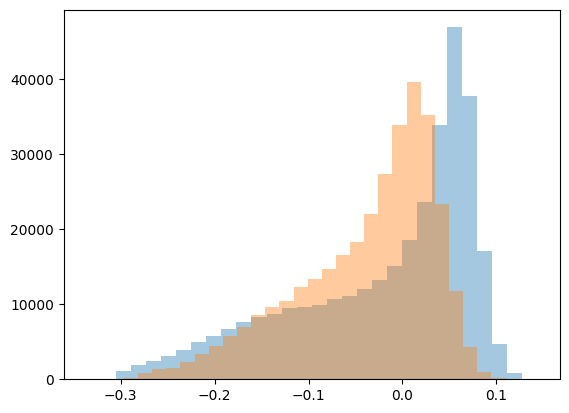

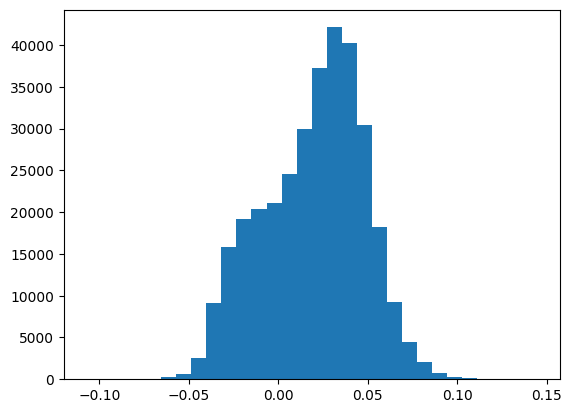

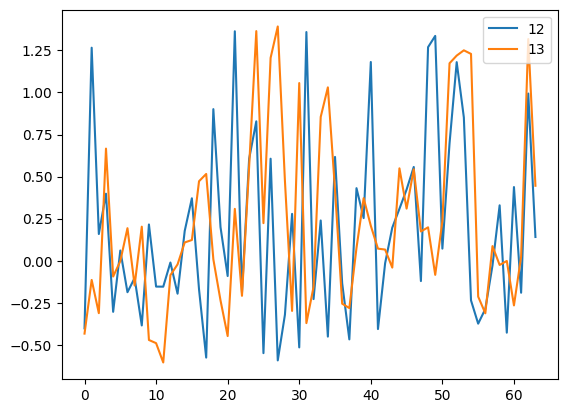

6.081151


In [15]:
def flatten(xss):
    return [x for xs in xss for x in xs]
plt.hist(flatten(res[2]), bins = 30, alpha = 0.4 )
plt.hist(flatten(res[1]), bins = 30, alpha = 0.4)
plt.show()
plt.hist(np.array(flatten(res[2])) - np.array(flatten(res[1])), bins = 30)
plt.show()





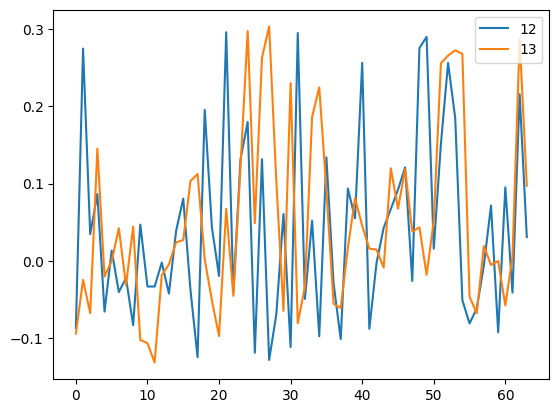

0.28794444


In [19]:
proto_normal = F.normalize(ppnet.prototype_vectors, p=2, dim=1)

vect1 =  proto_normal[12]
vect2 =  proto_normal[13]
plt.plot(vect1.cpu().detach().numpy()[:,0,0], label = 12)
plt.plot(vect2.cpu().detach().numpy()[:,0,0], label = 13)
plt.legend()
plt.show()

print(np.sum(vect1.cpu().detach().numpy()[:,0,0]*vect2.cpu().detach().numpy()[:,0,0]))

In [4]:
last_checkpoint = os.path.join('/home/ines/televit_xai/results/checkpoints/push_best.pth')
#checkpoint = torch.load('/home/ines/televit_xai/logs/train/runs/2024-11-14_20-06-56/checkpoints/epoch_013.ckpt')
if os.path.exists(last_checkpoint):
    ppnet = torch.load(last_checkpoint)
    ppnet = ppnet.cuda()


res = [ [] for i in range(10)]
for file in batch_files:
    for i in range(10):
        inputs_tensor, image, ground_truth = get_image_gt(file)
        fire = np.where(ground_truth == 1, 1, np.nan)
        mask_nan = np.isnan(fire)

        pred,proto_act_img_j = get_similarity_pred(inputs_tensor, 10 + i )
        res[i].append(list(proto_act_img_j[~mask_nan]))

/tmp/ipykernel_3789506/2492693510.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ppnet = torch.load(last_checkpoint)


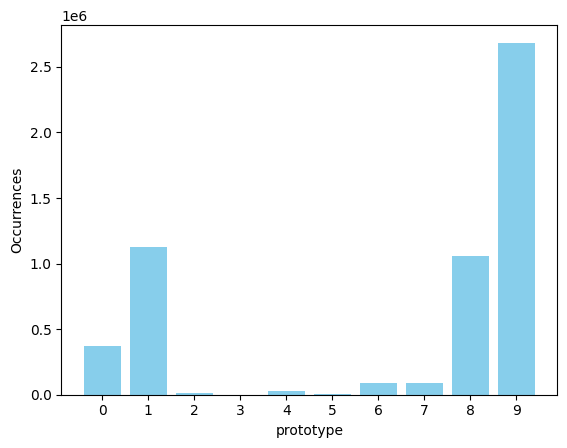

In [5]:
def flatten(xss):
    return [x for xs in xss for x in xs]

from collections import Counter

proto_activ = np.argmax([flatten(res[i]) for i in range(10)], axis = 0)

counter = Counter(proto_activ)



values = list(range(10))  # Ensuring all values from 0 to 9 are present
counts = [counter.get(value, 0) for value in values]

# Create the histogram
plt.bar(values, counts, tick_label=values, color='skyblue')
plt.xlabel('prototype')
plt.ylabel('Occurrences')
plt.show()


(array([11353., 14017., 18315., 25752., 33904., 40661., 44300., 37830.,
        30946., 71848.]),
 array([-0.31925571, -0.18733379, -0.05541189,  0.07651003,  0.20843193,
         0.34035385,  0.47227576,  0.60419768,  0.73611957,  0.86804152,
         0.9999634 ]),
 <BarContainer object of 10 artists>)

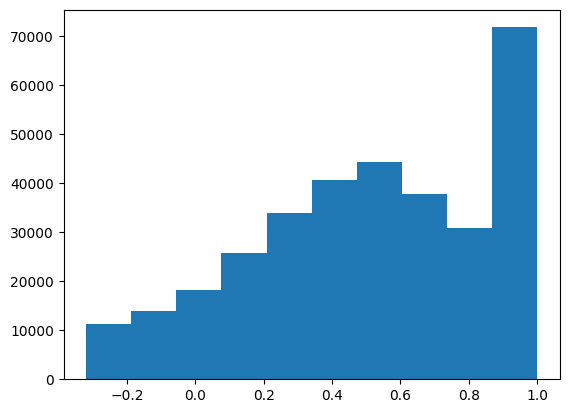

In [6]:
plt.hist(flatten(res[8]))

{'whiskers': [<matplotlib.lines.Line2D at 0x7fabc25eccd0>,
 'caps': [<matplotlib.lines.Line2D at 0x7fab6ca61760>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fabd14d8460>,
 'medians': [<matplotlib.lines.Line2D at 0x7fab706f3e20>,
 'fliers': [<matplotlib.lines.Line2D at 0x7fab706e8610>,
 'means': []}

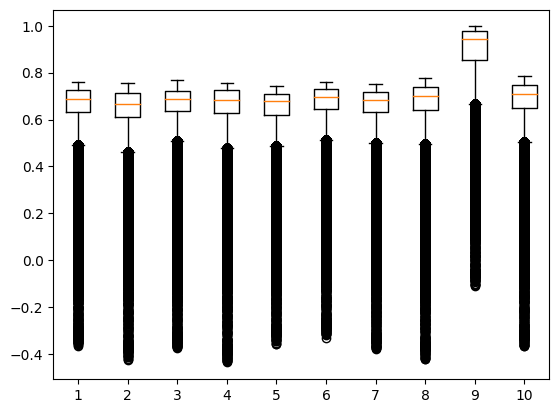

In [11]:
for i in range(10):
    res[i] = flatten(res[i])

plt.boxplot(res)

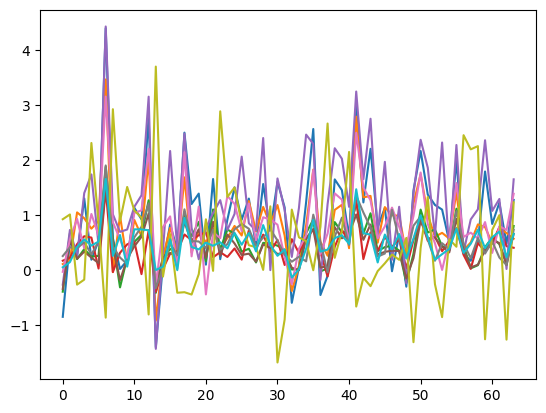

In [7]:

for vect in  ppnet.prototype_vectors[10:]:
    plt.plot(vect.cpu().detach().numpy()[:,0,0])